In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
%matplotlib notebook

data = scipy.io.loadmat('M56E_att40_2023_10_24_R2_wake_whole_FOV_32_stim.mat')
dF_wake = data['dF_wake']
dF_trial_wake = data['dF_trial_wake']
data = scipy.io.loadmat('M56E_att40_2023_10_20_R13_sleep_whole_FOV_32_stim.mat')
dF_sleep = data['dF_sleep']
dF_trial_sleep = data['dF_trial_sleep']

<IPython.core.display.Javascript object>


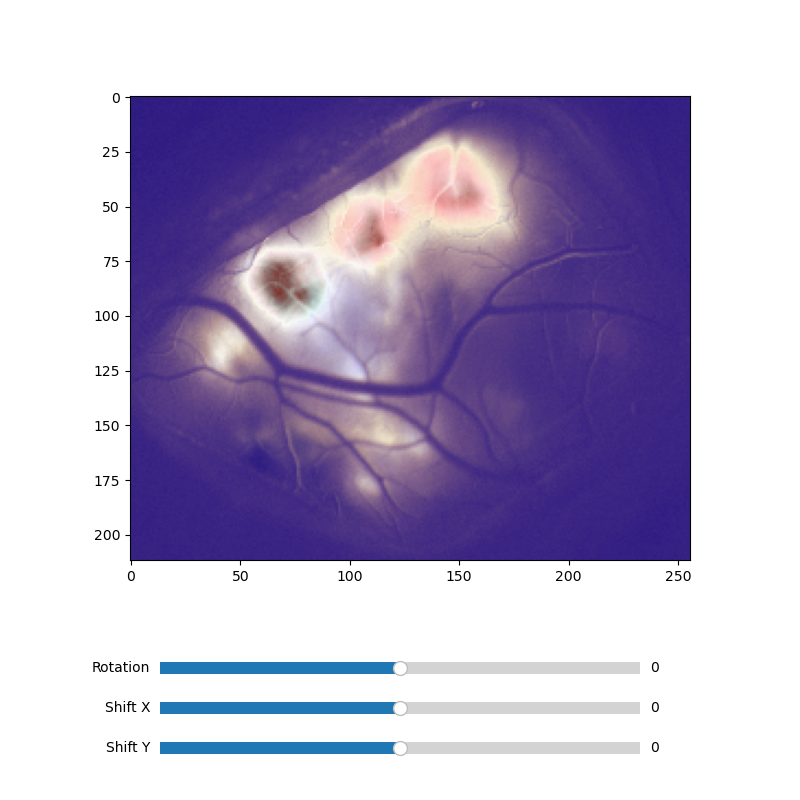

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from skimage.transform import rotate
from scipy.ndimage import shift

# Compute mean images
dF_wake_mean = np.mean(dF_wake, axis=2)  # (212, 256)
dF_sleep_mean = np.mean(dF_sleep, axis=2)  # (212, 256)

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 8))
plt.subplots_adjust(bottom=0.3)  # Adjust space for sliders

# Display the wake image as the fixed background
ax.imshow(dF_wake_mean, cmap="bwr", alpha=1.0)  # Reference image

# Overlay sleep image (this will be updated interactively)
sleep_im = ax.imshow(dF_sleep_mean, cmap="BrBG", alpha=0.5)  # Initial overlay

# Create sliders for rotation and translation
ax_slider_rot = plt.axes([0.2, 0.15, 0.6, 0.03])
slider_rot = Slider(ax_slider_rot, "Rotation", -30, 30, valinit=0, valstep=0.5)

ax_slider_x = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_x = Slider(ax_slider_x, "Shift X", -50, 50, valinit=0, valstep=1)

ax_slider_y = plt.axes([0.2, 0.05, 0.6, 0.03])
slider_y = Slider(ax_slider_y, "Shift Y", -50, 50, valinit=0, valstep=1)

# Function to update the image when sliders change
def update(val):
    angle = slider_rot.val
    shift_x = slider_x.val
    shift_y = slider_y.val
    
    # Rotate first, then shift
    rotated_sleep = rotate(dF_sleep_mean, angle, resize=False, mode="edge")
    shifted_sleep = shift(rotated_sleep, shift=(shift_y, shift_x), mode="nearest")

    sleep_im.set_data(shifted_sleep)
    fig.canvas.draw_idle()

# Connect sliders to update function
slider_rot.on_changed(update)
slider_x.on_changed(update)
slider_y.on_changed(update)

plt.show()


<IPython.core.display.Javascript object>


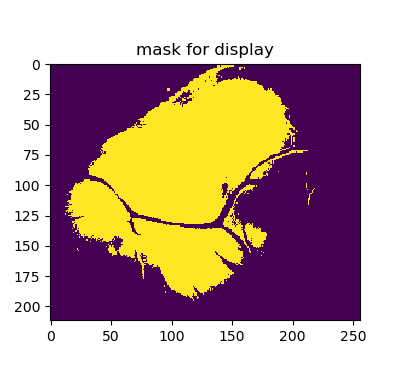

Text(0.5, 1.0, 'mask for display')

In [3]:
shifted = [ 0 , 0 ]
dF_sleep_aligned = shift(dF_sleep, shift=(shifted[1], shifted[0], 0), mode='nearest')
dF_sleep_aligned_mean = np.mean(dF_sleep_aligned, axis=2)
pixel_mask = (dF_wake_mean+dF_sleep_aligned_mean > 0.0125 ) #>>>>>>>>>>>>>masks for this and next cell
fig, axs = plt.subplots(1, 1, figsize=(4, 3.8))

im1 = axs.imshow(pixel_mask, interpolation='none')
axs.set_title('mask for display')
# plt.colorbar(im1, ax=axs, fraction=0.046, pad=0.04)

<IPython.core.display.Javascript object>


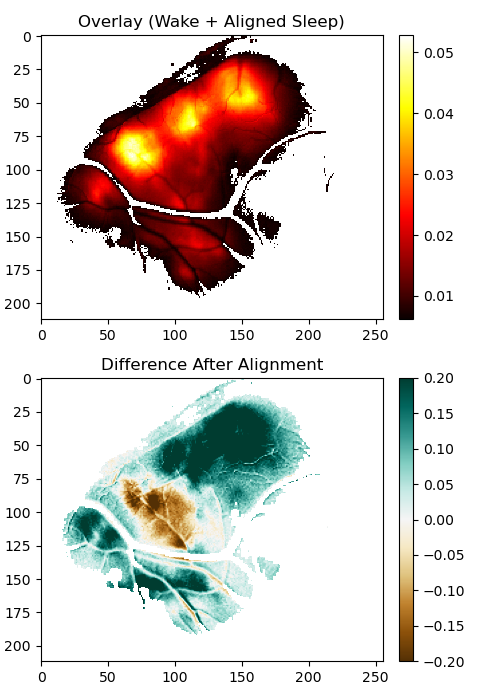

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(4.8, 7))

overlay = 0.5 * dF_wake_mean + 0.5 * dF_sleep_aligned_mean  # Blended overlay
overlay_masked = np.ma.masked_where(~pixel_mask, overlay)

im1 = axs[0].imshow(overlay_masked, cmap='hot', interpolation='none')
axs[0].set_title('Overlay (Wake + Aligned Sleep)')
# axs[0].axis('off')
plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)

# difference = dF_sleep_aligned_mean - dF_wake_mean
df_diff = np.sum(dF_wake, axis=2) - np.sum(dF_sleep_aligned, axis=2)
df_diff_masked = np.ma.masked_where(~pixel_mask, df_diff)

# im2 = axs[1].imshow(difference, cmap='bwr', vmin=-np.max(np.abs(difference)), vmax=np.max(np.abs(difference)))
im2 = axs[1].imshow(df_diff_masked, cmap='BrBG',vmin = -0.2, vmax = 0.2)
    
axs[1].set_title('Difference After Alignment')
# axs[1].axis('off')
plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
plt.savefig('M56E_att40_2023Oct_24vs20_response_diff.pdf')
plt.tight_layout()
plt.show()

In [5]:
# Reshape to combine stimuli and trials for statistical comparison
sleep_trials = dF_trial_sleep.reshape(212, 256, -1)  # (212, 256, 32*40)
wake_trials = dF_trial_wake.reshape(212, 256, -1)  # (212, 256, 32*20)
sleep_trials_aligned = shift(sleep_trials, shift=(shifted[1], shifted[0], 0), mode='nearest')

# Initialize arrays for p-values and t-values
p_values = np.ones((212, 256))
t_values = np.zeros((212, 256))

# Perform pixel-wise statistical comparison
for i in range(212):
    for j in range(256):
        t, p = ttest_ind(wake_trials[i, j, :], sleep_trials_aligned[i, j, :], equal_var=False, nan_policy='omit')
        t_values[i, j] = t
        p_values[i, j] = p

# Avoid log10(0) by setting a minimum threshold for p-values
p_values[p_values == 0] = 1e-10

# Convert p-values to log10 scale
log_p_values = -np.log10(p_values)

<IPython.core.display.Javascript object>


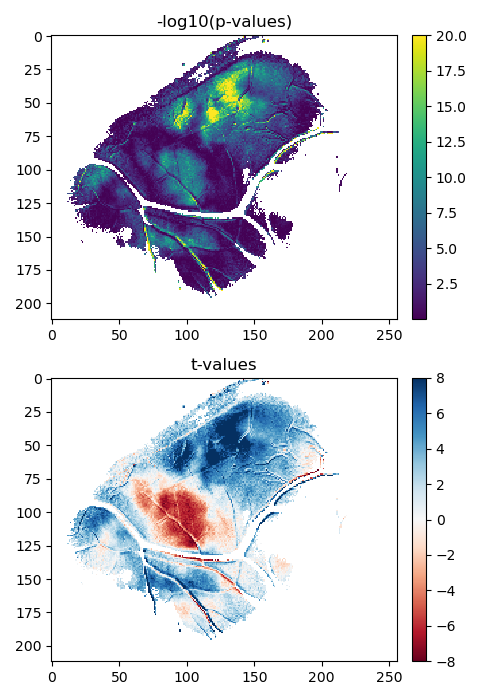

In [7]:
# Apply the mask to log_p_values and t_values
log_p_values_masked = np.ma.masked_where(~pixel_mask, log_p_values)
t_values_masked = np.ma.masked_where(~pixel_mask, t_values)

# Plot the masked log_p_values and t_values
fig, axs = plt.subplots(2, 1, figsize=(4.8, 7))

# Plot -log10(p-values)
p_disp_min = 0.05
p_disp_max = 20
im1 = axs[0].imshow(log_p_values_masked, aspect='auto', interpolation='none', cmap='viridis',
                    vmin=p_disp_min, vmax=p_disp_max)
axs[0].set_title('-log10(p-values)')
plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)

# Plot t-values
t_disp_min = -8   # Lower limit for t-values
t_disp_max = 8    # Upper limit for t-values
im2 = axs[1].imshow(t_values_masked, aspect='auto', interpolation='none', cmap='RdBu', 
                    vmin=t_disp_min, vmax=t_disp_max)
axs[1].set_title('t-values')
plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)
plt.savefig('M56E_att40_2023Oct_24vs20_t_values.pdf')
plt.tight_layout()
plt.show()
